<a href="https://colab.research.google.com/github/Sanpie34/SQL-Intermediate-Data-Analysis/blob/Kei/SQL_Int_Visualize_Result.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Customer Segmentation

In [3]:
customer_segmentation = pd.read_csv('customer_segmentation.csv')
customer_segmentation

,total_ltv,customer_segment,customer_count,avg_ltv
0,1.354293e+08,3 - High Value,12372,10946.433662
1,6.663645e+07,2 - Mid Value,24743,2693.143588
2,4.341810e+06,1 - Low-Value,12372,350.938371


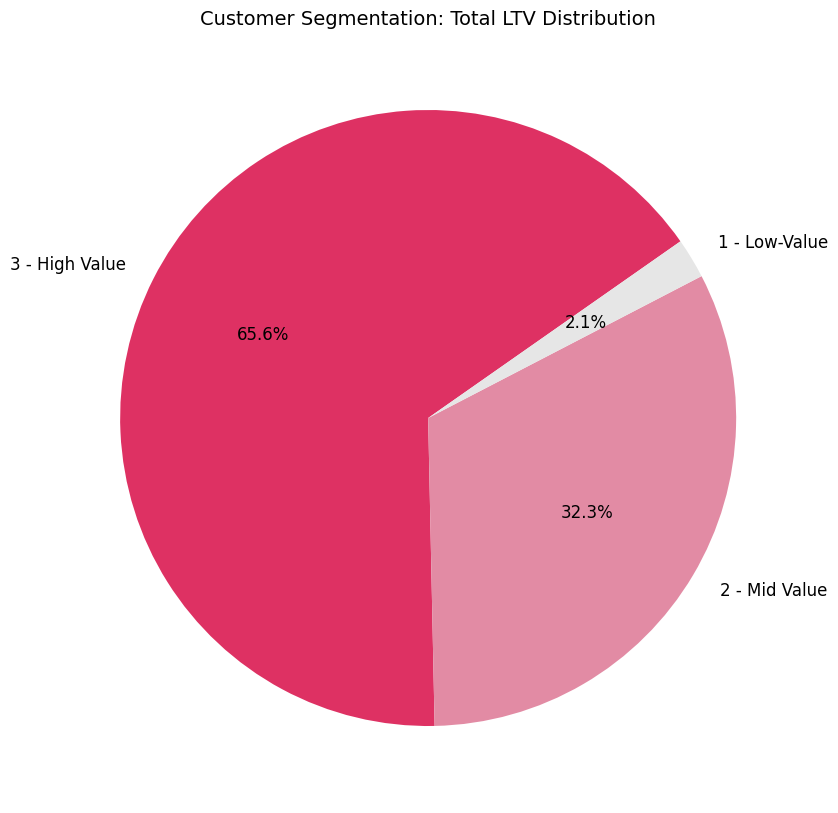

In [45]:
import matplotlib.colors as mcolors

def generate_shades(color_hex, n_shades):
    rgb = mcolors.hex2color(color_hex)
    # Create a colormap from a single color to white/black for lightness variations
    cmap = mcolors.LinearSegmentedColormap.from_list("mycmap", [rgb, (0.9, 0.9, 0.9)], N=n_shades) # From color to light gray
    # Alternatively, for darker shades:
    #cmap = mcolors.LinearSegmentedColormap.from_list("mycmap", [rgb, (0.1, 0.1, 0.1)], N=n_shades)
    return [cmap(i) for i in range(n_shades)]

num_segments = len(customer_segmentation['customer_segment'])
colors = generate_shades('#DE3163', num_segments)

fig, ax = plt.subplots(figsize=(10, 10))
ax.pie(customer_segmentation['total_ltv'], labels=customer_segmentation['customer_segment'], autopct='%1.1f%%', startangle=35, textprops={'fontsize': 12}, colors=colors)
ax.set_title('Customer Segmentation: Total LTV Distribution', fontsize=14)
plt.show()

In [15]:
cohort_analysis = pd.read_csv('cohort_analysis.csv')
cohort_analysis

,cohort_year,total_revenue,customer_revenue
0,2015,7.245613e+06,2825
1,2016,9.839134e+06,3397
2,2017,1.177150e+07,4068
3,2018,1.977377e+07,7446
4,2019,2.224506e+07,7755
5,2020,7.058615e+06,3031
6,2021,1.197408e+07,4663
7,2022,2.150755e+07,9010
8,2023,1.289058e+07,5890
9,2024,2.764780e+06,1402


In [16]:
cohort_analysis['cohort_year'] = cohort_analysis['cohort_year'].astype(str)
cohort_analysis

,cohort_year,total_revenue,customer_revenue
0,2015,7.245613e+06,2825
1,2016,9.839134e+06,3397
2,2017,1.177150e+07,4068
3,2018,1.977377e+07,7446
4,2019,2.224506e+07,7755
5,2020,7.058615e+06,3031
6,2021,1.197408e+07,4663
7,2022,2.150755e+07,9010
8,2023,1.289058e+07,5890
9,2024,2.764780e+06,1402


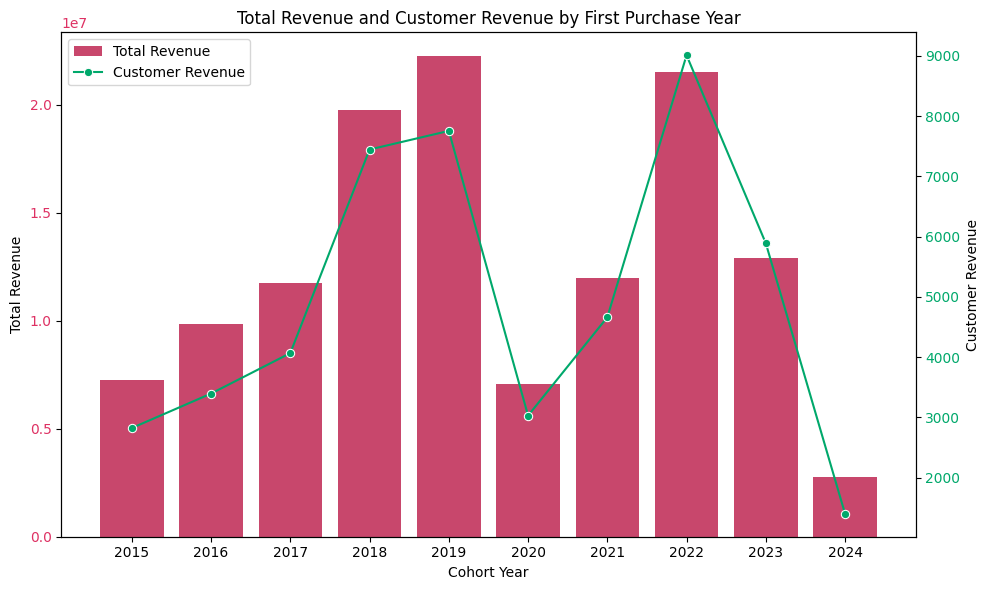

In [40]:
fig, ax1 = plt.subplots(figsize=(10, 6))


sns.barplot(data=cohort_analysis, x='cohort_year', y='total_revenue', color='#DE3163', ax=ax1, label='Total Revenue', legend = False)
ax1.set_xlabel('Cohort Year')
ax1.set_ylabel('Total Revenue', color='black')
ax1.tick_params(axis='y', labelcolor='#DE3163')

ax2 = ax1.twinx()
sns.lineplot(data=cohort_analysis, x='cohort_year', y='customer_revenue', color='#00A86B', marker='o', ax=ax2, label='Customer Revenue')
ax2.set_ylabel('Customer Revenue', color='black')
ax2.tick_params(axis='y', labelcolor='#00A86B')


lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax2.legend(lines + lines2, labels + labels2, loc='upper left')

plt.title('Total Revenue and Customer Revenue by First Purchase Year')
plt.tight_layout()
plt.show()

In [23]:
retention_analysis = pd.read_csv('retention_analysis.csv')
retention_analysis

,cohort_year,customer_status,num_customers,total_customers,status_percentage
0,2015,Active,237,2825,8.39
1,2015,Churned,2588,2825,91.61
2,2016,Active,311,3397,9.16
3,2016,Churned,3086,3397,90.84
4,2017,Active,385,4068,9.46
5,2017,Churned,3683,4068,90.54
6,2018,Active,704,7446,9.45
7,2018,Churned,6742,7446,90.55
8,2019,Active,687,7755,8.86
9,2019,Churned,7068,7755,91.14


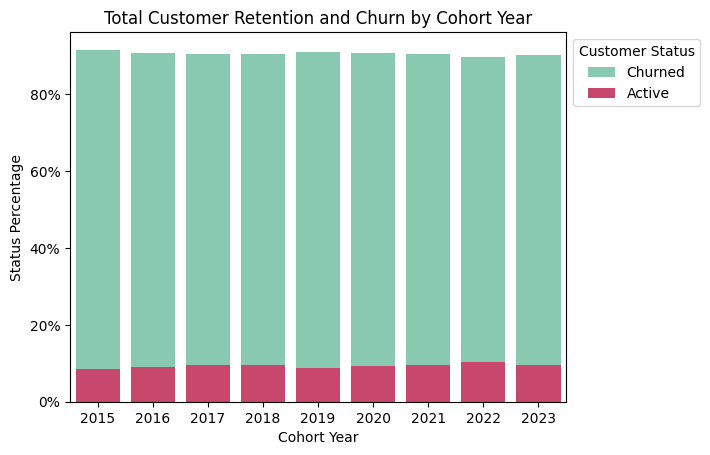

In [42]:
df_a = retention_analysis[retention_analysis['customer_status'] == 'Active']
df_c = retention_analysis[retention_analysis['customer_status'] == 'Churned']


ax = sns.barplot(data = df_c, x = 'cohort_year', y = 'status_percentage', color = '#00A86B', alpha=0.5, label = 'Churned')
sns.barplot(data = df_a, x = 'cohort_year', y = 'status_percentage', color = '#DE3163', label = 'Active')

plt.legend(title='Customer Status', loc='upper left', bbox_to_anchor=(1, 1))
plt.title('Total Customer Retention and Churn by Cohort Year')
plt.xlabel('Cohort Year')
plt.ylabel('Status Percentage')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f"{int(x)}%"))
plt.show()